<a href="https://colab.research.google.com/github/Auta01/Pytorch/blob/main/pretrained%20modelwith%20pytorch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download('https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Auta01
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:02<00:00, 63.3MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
train_df =pd.read_csv('/content/bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('/content/bean-leaf-lesions-classification/val.csv')

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [4]:
print(train_df.shape)
print(val_df.shape)

(1034, 2)
(133, 2)


In [5]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [6]:
transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])


In [7]:
class CustomImageDatasets:
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category'], device=device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = os.path.join('/content/bean-leaf-lesions-classification', self.dataframe.iloc[idx, 0])
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB') # Ensure image is in RGB format

    if self.transform:
     image = self.transform(image).to(device)
    return image, label

In [8]:
train_dataset = CustomImageDatasets(dataframe = train_df, transform = transforms )
val_dataset = CustomImageDatasets(dataframe = val_df, transform = transforms)

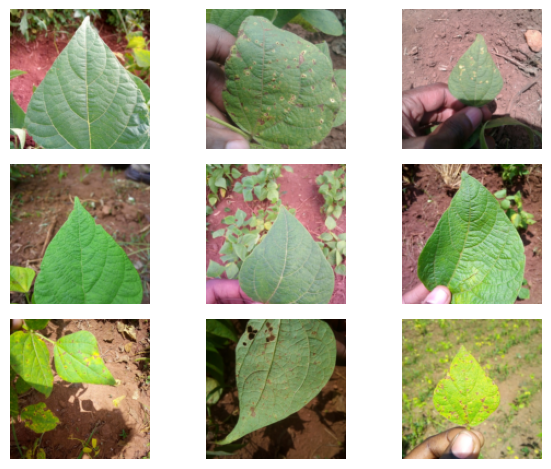

In [9]:
n_row = 3
n_cols = 3

f, axarr = plt.subplots(n_row, n_cols)

for row in range(n_row):
  for col in range (n_cols):
    idx = np.random.randint(0, len(train_dataset)) # Correctly get a random index
    image_tensor, _ = train_dataset[idx] # Get image tensor and discard label
    # Convert PyTorch tensor to numpy array with channels last for imshow
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    axarr[row, col].imshow(image_np)
    axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

In [10]:
LR = 1e-3
BATCH_SIZE = 4
Epochs = 5

train_loader = DataLoader(train_dataset, batch_size =BATCH_SIZE,shuffle = True)
val_loader  =  DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle = True)

In [11]:
googlenet_model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 126MB/s]


In [12]:
for param in googlenet_model.parameters():
  param.requires_grad = True
  googlenet_model.fc

In [13]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [14]:
num_classes = len(train_df['category'].unique())
num_classes

3

In [15]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [16]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(Epochs):
  total_loss_train = 0.0
  total_acc_train = 0.0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    predictions = torch.argmax(outputs, axis=1)
    train_acc = (predictions == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4))
  total_acc_train_plot.append(round(total_acc_train / train_dataset.__len__() * 100, 4))

  print(f'Epoch {epoch + 1}/{Epochs}, Train loss:{round(total_loss_train / len(train_loader), 4)}, Train Accuracy:{round(total_acc_train / train_dataset.__len__() * 100, 4)}%')

Epoch 1/5, Train loss:0.8325, Train Accuracy:65.4739%
Epoch 2/5, Train loss:0.6136, Train Accuracy:76.1122%
Epoch 3/5, Train loss:0.5741, Train Accuracy:77.4662%
Epoch 4/5, Train loss:0.4443, Train Accuracy:84.3327%
Epoch 5/5, Train loss:0.4401, Train Accuracy:83.9458%


In [18]:
googlenet_model.eval()
with torch.no_grad():
  total_loss_val = 0.0
  total_acc_val = 0.0

  for inputs, labels in val_loader:

    prediction = googlenet_model(inputs)
    acc = (torch.argmax(prediction, axis =1)==labels).sum().item()
    total_acc_test = acc
  print(f' {round(total_acc_test / val_dataset.__len__()*100,4)}')


 0.7519


In [19]:
#Transfer learninng
for param in googlenet_model.parameters():
  param.requires_grad = False
  googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
  googlenet_model.to(device)


In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(Epochs):
  total_loss_train = 0.0
  total_acc_train = 0.0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    predictions = torch.argmax(outputs, axis=1)
    train_acc = (predictions == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4))
  total_acc_train_plot.append(round(total_acc_train / train_dataset.__len__() * 100, 4))

  print(f'Epoch {epoch + 1}/{Epochs}, Train loss:{round(total_loss_train / len(train_loader), 4)}, Train Accuracy:{round(total_acc_train / train_dataset.__len__() * 100, 4)}%')

Epoch 1/5, Train loss:0.171, Train Accuracy:94.6809%
Epoch 2/5, Train loss:0.0931, Train Accuracy:96.7118%
Epoch 3/5, Train loss:0.0911, Train Accuracy:96.6151%
Epoch 4/5, Train loss:0.0822, Train Accuracy:96.9052%
Epoch 5/5, Train loss:0.0782, Train Accuracy:97.3888%
